# Завдання

- вибрати дані для класифікації бінарної (спочатку синтетичні)
- показати їх
- загрузити їх
- трейн і тест для х та у
- навчити модель
- евалювати її

# Ліби

In [152]:

import matplotlib.pyplot as plt

from sklearn.datasets import (make_classification, load_wine, load_iris, load_breast_cancer)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score

import pandas as pd
import numpy as np
import seaborn as sns

# Моє

Привести до купи:
- як поведе себе гіт із файлом 4
- ~~як поведе себе гіт із папкою 5~~
- візуалізувати синтетичні
- кросвалідацію на бінарний ірис
- чого бінарний ірис так просідає?
- дати норм візуаілізацію ірисам
- порефакторити

## Синтетичні дані

In [2]:
X_simple, y_simple = make_classification(
    n_samples=500,
    n_features=2,          # 👈 важливо! для візуалізації
    n_informative=2,
    n_redundant=0,#?
    n_clusters_per_class=1,
    class_sep=1.5,         # 👈 наскільки легко розділити
    flip_y=0.04,
    random_state=42
)
type(X_simple), X_simple.shape, y_simple.shape  

(numpy.ndarray, (500, 2), (500,))

In [3]:
X_simple[:5]

array([[ 0.75682995, -1.09912807],
       [ 2.37384662, -3.96976419],
       [ 2.28730337, -3.00222426],
       [ 1.69668341, -1.13445852],
       [ 2.77894589,  2.33784428]])

In [4]:
np.unique(y_simple)

array([0, 1])

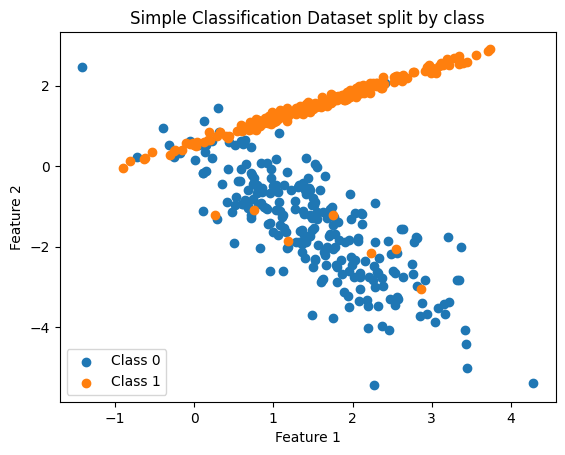

In [5]:
# plt.plot(X_simple[:, 0], X_simple[:, 1], 'o')
plt.figure()

for cls in np.unique(y_simple):
    plt.scatter(
        X_simple[y_simple == cls, 0],
        X_simple[y_simple == cls, 1],
        label=f"Class {cls}"
    )
plt.title("Simple Classification Dataset split by class")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

In [6]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple =  train_test_split(
    X_simple,
    y_simple,
    stratify=y_simple, # зберігаємо пропорції класів у вибірках
    random_state=42,
)


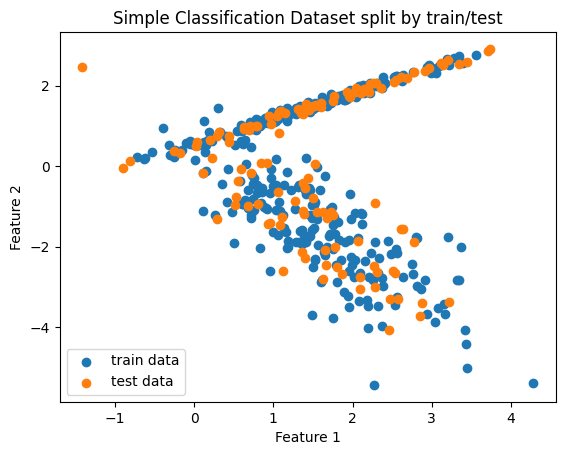

In [7]:
plt.figure()

for t, d in {'train': X_train_simple, 'test': X_test_simple}.items():
    plt.scatter(
        d[:, 0],
        d[:, 1],
        label=f"{t} data"
    )
plt.title("Simple Classification Dataset split by train/test")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

In [8]:
y2d = y_simple.reshape(-1, 1)
df_y = pd.DataFrame(y2d, columns=['target'])
print('Check if class is balanced')
df_y.value_counts()

Check if class is balanced


target
1         254
0         246
Name: count, dtype: int64

Шо на цьому етапі робив тіп
1. Тоже згенерив датасет так само
2. сплітнув
3. дф intro_frame весь і мітки як в оригіналі (нашо???) для візуалізації??
4. дф split_frame те саме, але спочатку трейн а потім тестові + колонка з тим чи тестові чи ні
5. дф balance_frame де просто кількість класів - перевірка чи збалансований

6. просто показав, як працює сигмоїд?

7. просто показав, я працює кросентропія?

8. знов генерить штучні дані
9. сплітить
10. просто виводить показуючи різними кольорами класи

## Реальні дані

### load data

In [30]:
breast = load_breast_cancer()
df_breast = pd.DataFrame(breast.data, columns=breast.feature_names)
df_breast['target'] = breast.target
df_breast.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [31]:
df_breast['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    df_breast.drop('target', axis=1),
    df_breast['target'],
    random_state=42
)

### iris

In [41]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
df_iris['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [61]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### binary classification

In [47]:
df_iris_2 = df_iris[df_iris['target'] != 0]
df_iris_2['target'].unique()

array([1, 2])

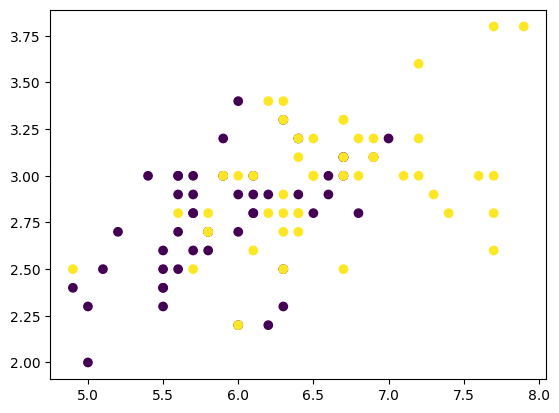

In [59]:
plt.scatter(df_iris_2['sepal length (cm)'], df_iris_2['sepal width (cm)'], c=df_iris_2['target'])

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    df_iris_2.drop('target', axis=1),
    df_iris_2['target'],
    
    random_state=42
)

In [ ]:
# logreg = Pipeline(
#     [
#         ("scaler", StandardScaler()),
#         ("model", LogisticRegression(C=1.0, max_iter=2000)),
#     ]
# )

In [140]:
logreg = Pipeline([
    # ("poly", PolynomialFeatures(degree=3)), # both commented lines returns same results
    # ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

In [141]:
logreg.fit(X_train, y_train)

Pipeline(steps=[('logreg', LogisticRegression(max_iter=2000))])

In [142]:
pred = logreg.predict(X_test)

In [143]:
print(f"accuracy: {accuracy_score(y_test, pred)}\nprecision: {precision_score(y_test, pred, zero_division=0)}\nrecall: {recall_score(y_test, pred, zero_division=0)}\nf1: {f1_score(y_test, pred, zero_division=0)}")

accuracy: 0.92
precision: 0.9285714285714286
recall: 0.9285714285714286
f1: 0.9285714285714286


#### multiclass clasification

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    df_iris.drop('target', axis=1),
    df_iris['target'],
    
    random_state=42
)

In [145]:
logreg = Pipeline([
    ('logreg', LogisticRegression(max_iter=2000))
])

In [146]:
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

In [147]:
cm_iris = confusion_matrix(y_test, pred)

<Axes: >

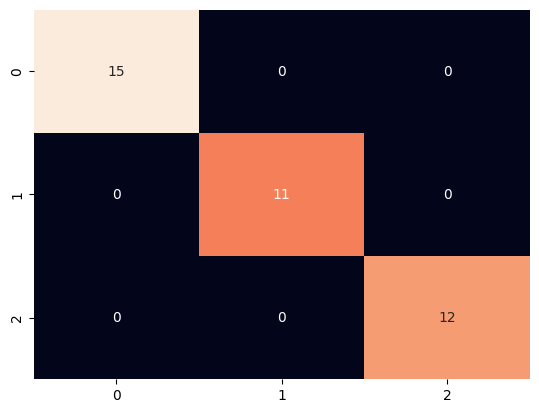

In [ ]:
sns.heatmap(
    cm_iris,
    annot=True,
    fmt="d",
    cbar=False)

In [151]:
accuracy_score(y_test, pred)

1.0

In [153]:
cross_val_score(logreg,  df_iris.drop('target', axis=1), df_iris['target'], cv=5)

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])

# log reg

11. створює пайплайн 

In [9]:
logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000)),
    ]
)

12. фітить

In [10]:
logreg.fit(X_train_simple, y_train_simple)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

13. предіктить мітки і ймовірності (нашо другі і чому лише один клас??)

In [11]:
pred = logreg.predict(X_test_simple)

14. юзає свій метод для метрик

In [12]:
print(f"accuracy: {accuracy_score(y_test_simple, pred)}\nprecision: {precision_score(y_test_simple, pred, zero_division=0)}\nrecall: {recall_score(y_test_simple, pred, zero_division=0)}\nf1: {f1_score(y_test_simple, pred, zero_division=0)}")

accuracy: 0.928
precision: 0.921875
recall: 0.9365079365079365
f1: 0.9291338582677166


15. малює малюнок з допомогою plot_surface
- в ній є make_grid - який створює дані в кожній точці площини двох фіч - повертає сітку і дві комбінації
- далі score_on_grid для z - 


In [25]:
def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    x0_lin = np.linspace(x0_min, x0_max, n)
    x1_lin = np.linspace(x1_min, x1_max, n)

    xx, yy = np.meshgrid(x0_lin, x1_lin)

    # print(x0_lin[:5], '\n', x1_lin[:5])
    # print(x0_lin.shape, x1_lin.shape)
    # print(f"xx shape: {xx.shape}, yy shape: {yy.shape}")
    # print(f"xx sample:\n{xx[:5, :5]}\n")
    # print(f"yy sample:\n{yy[:5, :5]}\n")
    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()
    # print(xx_ravel[:5], '\n', yy_ravel[:5])
    grid = np.c_[xx_ravel, yy_ravel]
    print(f"Grid shape: {grid.shape}")
    print(f'xx shape: {xx.shape}, yy shape: {yy.shape}')
    return xx, yy, grid

In [31]:
def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        pred = model.predict_proba(grid) # приналежність до кожного класу кожного рядка
        print(pred[-5:], pred.shape)
        return pred[:, 1] #берем лише до другого класу
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)

In [46]:
import seaborn as sns
surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)
def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)
    # ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)

Grid shape: (90000, 2)
xx shape: (300, 300), yy shape: (300, 300)
[[7.26799960e-05 9.99927320e-01]
 [7.16671195e-05 9.99928333e-01]
 [7.06683575e-05 9.99929332e-01]
 [6.96835134e-05 9.99930316e-01]
 [6.87123933e-05 9.99931288e-01]] (90000, 2)


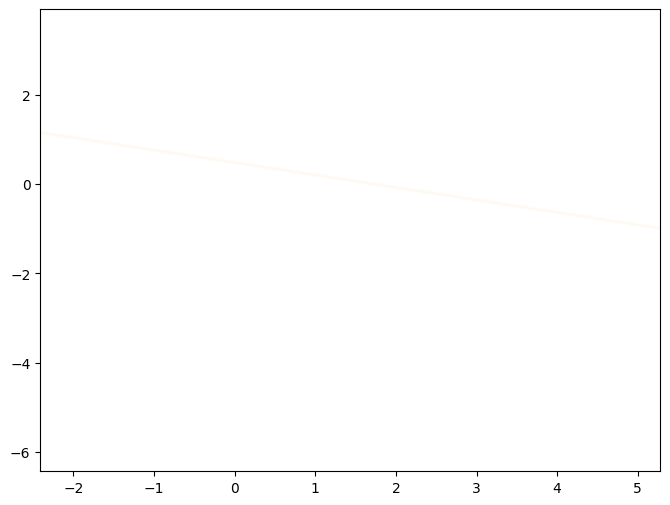

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_surface(ax=ax, model=logreg, X=X_simple, y=y_simple, title="Logistic Regression Decision Surface")
plt.show()

Grid shape: (90000, 2)
xx shape: (300, 300), yy shape: (300, 300)
[[7.26799960e-05 9.99927320e-01]
 [7.16671195e-05 9.99928333e-01]
 [7.06683575e-05 9.99929332e-01]
 [6.96835134e-05 9.99930316e-01]
 [6.87123933e-05 9.99931288e-01]] (90000, 2)


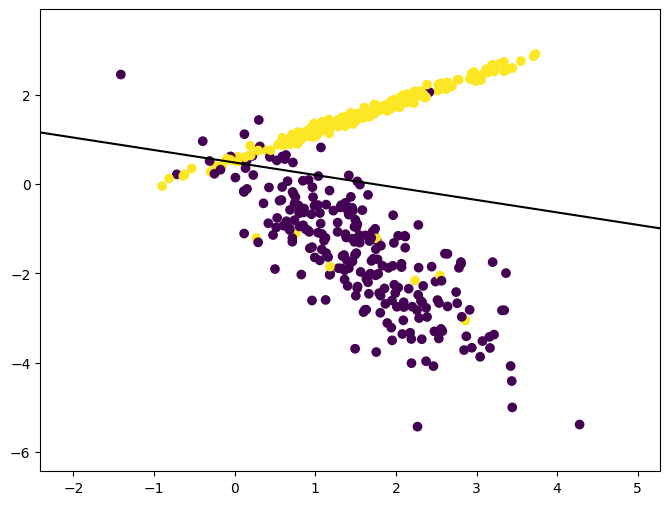

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy, grid = make_grid(X_simple)
z = score_on_grid(logreg, grid).reshape(xx.shape)
ax.contour(xx, yy, z, levels=[0.5], colors="black")
ax.scatter(X_simple[:, 0], X_simple[:, 1], c=y_simple)
plt.show()

15. Малює, що вийшло у моделі

16. генерить муни
17. сплітить муни
18. логістична регресія
19. логістична регресія **полі**
18. фітить обидві
19. знаходить мітки та імовірності для двох
20. СТворив дф для порівняння
21. плотить обидва

24. пробує, який краще трешхолд ставити

25. лоадить груди
26. пхне в дф
27. стандартизує тренувальни х
28. логрег робить
29. створює дф фіч, їх коефіцієнтів 
30. показує вадливість фіч

31. робить логспейс регуляризації
32. логрегресія + різін лр + регуляризація + якийсь солвер???
33. зробили кросвалідацію потім фітінг
34. створюємо фрейм з вагами та оцінками середніми в залежності від моделей
35. оцінює вплив регіляризації

### мультикласова

36. мультикласова логістична регресія
37. лоаднув вино
38. скелить, створює регресію
39. фітить
40. предіктить
41. конфюжн матриця
42. оформили ваги у датафрейм
43. список найвпливовіших фіч

In [54]:
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    stratify=y_wine,
    random_state=42,
)

wine_logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, solver="lbfgs", l1_ratio=0.0)),
    ]
)
wine_logreg.fit(X_train_w, y_train_w)
pred_wine = wine_logreg.predict(X_test_w)

c:\Users\redmi\anaconda3\envs\py310\lib\site-packages\sklearn\linear_model\_logistic.py:1106: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [58]:
wine_logreg.named_steps["model"].coef_.shape

(3, 13)

In [60]:
cm_wine = confusion_matrix(y_test_w, pred_wine)
coef_wine = pd.DataFrame(
    wine_logreg.named_steps["model"].coef_,
    columns=X_wine.columns,
    index=wine.target_names,
)
coef_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,0.720224,0.163085,0.467260,-0.813411,0.081381,0.221881,0.700162,-0.104754,0.138288,0.195067,0.088241,0.651525,0.918984
class_1,-0.841599,-0.509095,-0.789415,0.515609,-0.123434,0.051823,0.188283,0.126725,0.375156,-1.020619,0.677416,-0.112636,-0.937653
class_2,0.121375,0.346010,0.322155,0.297801,0.042053,-0.273704,-0.888445,-0.021971,-0.513444,0.825552,-0.765657,-0.538888,0.018669


In [65]:
top_wine_features = coef_wine.abs().mean(axis=0).sort_values(ascending=False).head(10).index
top_wine_features

Index(['color_intensity', 'proline', 'flavanoids', 'alcohol',
       'alcalinity_of_ash', 'ash', 'hue', 'od280/od315_of_diluted_wines',
       'proanthocyanins', 'malic_acid'],
      dtype='object')

# SVM